# Black-Litterman modular (para o backtest)

Funções extraídas do `bl.ipynb` com entradas explícitas (sem variáveis globais), uma por célula. As opiniões retornam apenas as visões `(P, Q, Ω)`; o prior usa pesos por market-cap (CVM) e o método grid usa B/M e size históricos do `ranking.csv`.

In [41]:
# ===========================================================================
# Funções modulares para o backtest Black-Litterman
# Extraídas das células exploratórias: entradas explícitas, sem variáveis
# globais. Cada função faz uma etapa do pipeline e pode ser chamada por rebalanceamento.
# ===========================================================================
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.covariance import LedoitWolf
from pypfopt import black_litterman
from pypfopt.black_litterman import BlackLittermanModel
import statsmodels.api as sm
import os
from pypfopt import risk_models, EfficientFrontier, EfficientCVaR

In [42]:
def _ler_tabela(x):
    """Aceita DataFrame, caminho .csv/.parquet ou None — devolve DataFrame/None."""
    if x is None or isinstance(x, pd.DataFrame):
        return x
    df = pd.read_parquet(x) if str(x).endswith(".parquet") else pd.read_csv(x)
    df.columns = [str(c).lstrip("﻿") for c in df.columns]
    return df

In [43]:
# --- 1) Universo e valores a partir do dados_backtest.csv ------------------
def obter_ativos_trimestre(dados_backtest, trimestre):
    """
    Tickers e market_cap (CVM) selecionados no `trimestre` (coluna de seleção).
    `dados_backtest`: DataFrame ou caminho do dados_backtest.csv.
    Retorna DataFrame [ticker, market_cap].
    """
    bt = _ler_tabela(dados_backtest)
    sub = bt[bt["trimestre"].astype(str) == str(trimestre)]
    sub = sub.dropna(subset=["ticker"]).drop_duplicates("ticker")
    return sub[["ticker", "market_cap"]].reset_index(drop=True)

In [44]:
# --- 2) Fatores Nefin ------------------------------------------------------
def obter_fatores_nefin(caminho="nefin_factors.csv", freq="ME"):
    """Carrega os fatores Nefin, remove colunas 'Unnamed' e agrega para mensal (composto)."""
    f = _ler_tabela(caminho)
    f = f.loc[:, ~f.columns.str.contains("^Unnamed")]
    f["Date"] = pd.to_datetime(f["Date"])
    f = f.set_index("Date")
    return (1 + f).resample(freq).prod() - 1

In [45]:
# --- 3) Preços e covariância ----------------------------------------------
def baixar_precos(tickers, inicio, fim, limiar=10):
    """Fechamento ajustado (yfinance); descarta colunas com muitos NaN e faz ffill."""
    syms = [f"{t}.SA" for t in tickers]
    px = yf.download(syms, start=inicio, end=fim, auto_adjust=True, progress=False)["Close"]
    if isinstance(px, pd.Series):
        px = px.to_frame()
    px.columns = [str(c).replace(".SA", "") for c in px.columns]
    px = px.dropna(axis=1, thresh=len(px) - limiar).ffill()
    return px

In [46]:
def matriz_covariancia(returns):
    """Covariância por Ledoit-Wolf (encolhimento)."""
    cov = LedoitWolf().fit(returns).covariance_
    return pd.DataFrame(cov, index=returns.columns, columns=returns.columns)

In [47]:
# --- 4) Valores do modelo Black-Litterman ---------------------------------
def calcular_prior(cov_matrix, market_caps, delta=3.07):
    """
    Prior (PI = retornos implícitos do mercado) ponderado por market-cap.
    `market_caps`: Series/dict indexado por ticker; usa só os tickers da cov.
    """
    tickers = list(cov_matrix.columns)
    mc = pd.Series(market_caps).reindex(tickers).astype(float)
    w = mc / mc.sum()
    pesos = dict(zip(tickers, w.values))
    return black_litterman.market_implied_prior_returns(pesos, delta, cov_matrix)

In [48]:
def preparar_bl(prices, fatores_mensais, market_caps, delta=None):
    """
    Monta os blocos do BL em escala MENSAL:
      - retornos e fatores mensais alinhados pelas datas comuns,
      - cov (Ledoit-Wolf) e prior (PI por market-cap).
    delta: se None, usa a aversao ao risco IMPLICITA do mercado
    (market_implied_risk_aversion sobre o portfolio de mercado cap-weighted dos
    ativos, base mensal, com rf dos fatores Nefin). Sem look-ahead.
    Retorna dict {returns, fatores, cov, prior, delta, tickers}.
    """
    ret_mensal = (1 + prices.pct_change().dropna()).resample("ME").prod() - 1
    datas = ret_mensal.index.intersection(fatores_mensais.index)
    ret = ret_mensal.loc[datas]
    fat = fatores_mensais.loc[datas]
    cov = matriz_covariancia(ret)

    if delta is None:
        # portfolio de mercado = cap-weighted dos ativos -> delta implicito (mensal)
        cols = [c for c in prices.columns if c in pd.Series(market_caps).index]
        wm = pd.Series(market_caps).reindex(cols).astype(float)
        wm = wm / wm.sum()
        mkt = (1 + (prices[cols].pct_change().dropna() * wm).sum(axis=1)).cumprod()
        mkt_mensal = mkt.resample("ME").last().reindex(ret.index).dropna()
        rf_anual = (1 + fat["Risk_Free"].mean()) ** 12 - 1 if "Risk_Free" in fat else 0.02
        delta = float(black_litterman.market_implied_risk_aversion(
            mkt_mensal, frequency=12, risk_free_rate=rf_anual))
        if not np.isfinite(delta) or delta <= 0:
            delta = 3.07

    prior = calcular_prior(cov, market_caps, delta)
    return {"returns": ret, "fatores": fat, "cov": cov,
            "prior": prior, "delta": delta, "tickers": list(cov.columns)}

In [49]:
def estimar_retornos_ff(returns_alinhados, fatores_alinhados, tickers,
                        col_rf="Risk_Free"):
    """
    Regressão Fama-French (OLS) por ativo. Para cada ticker, Y = retorno - rf.
    Retorna dict com betas, retornos estimados r̂_i (= alfa + betas·médias),
    variância dos resíduos, a matriz X e as médias dos fatores.
    """
    fatores_cols = [c for c in fatores_alinhados.columns if c != col_rf]
    X = sm.add_constant(fatores_alinhados[fatores_cols])
    medias = fatores_alinhados[fatores_cols].mean()
    betas, var_resid = {}, {}
    for t in tickers:
        Y = returns_alinhados[t] - fatores_alinhados[col_rf]
        m = sm.OLS(Y, X).fit()
        betas[t] = m.params
        var_resid[t] = m.mse_resid
    betas_df = pd.DataFrame(betas).T
    r_est = betas_df["const"] + betas_df[fatores_cols].dot(medias)
    return {"betas": betas_df, "retornos_estimados": r_est,
            "var_residuos": pd.Series(var_resid), "X": X,
            "medias_fatores": medias, "fatores_cols": fatores_cols, "col_rf": col_rf}

In [50]:
def bm_size_do_ranking(ranking, trimestre, tickers=None):
    """
    Book-to-market (VPA/preço) e size (market_cap) HISTÓRICOS do ranking.csv no
    trimestre dado — sem look-ahead. `ranking`: DataFrame ou caminho.
    Retorna (book_to_market, size) como Series indexadas por ticker.
    """
    rk = _ler_tabela(ranking)
    rk["trimestre"] = pd.to_datetime(rk["DT_FIM_EXERC"]).dt.to_period("Q").astype(str)
    sub = (rk[rk["trimestre"] == str(trimestre)]
           .dropna(subset=["ticker"]).drop_duplicates("ticker").set_index("ticker"))
    if tickers is not None:
        sub = sub.reindex([t for t in tickers if t in sub.index])
    bm = (sub["vpa"] / sub["preco"]).replace([np.inf, -np.inf], np.nan).dropna()
    size = sub["market_cap"].dropna()
    return bm, size

In [51]:
def posterior_bl(cov_matrix, prior, P, Q, Omega, tickers, tau=0.1):
    """Retornos posteriores Black-Litterman (mu_BL) para o universo `tickers`."""
    cov = cov_matrix.loc[tickers, tickers]
    bl = BlackLittermanModel(cov, pi=pd.Series(prior).reindex(tickers),
                             Q=Q, P=P, omega=Omega, tau=tau)
    return bl.bl_returns()

In [52]:
def opiniao_individual(retornos_estimados, var_residuos, tickers):
    """
    Visões ABSOLUTAS (intuitivas): cada ativo tem sua própria visão = r̂_i
    previsto pelo Fama-French.
        P  = identidade (cada visão se refere a um único ativo)
        Q  = retornos estimados r̂_i
        Ω  = diagonal com a variância dos resíduos da regressão de cada ativo
    Retorna (P, Q, Omega, tickers).
    """
    tickers = list(tickers)
    P = np.eye(len(tickers))
    Q = pd.Series(retornos_estimados).reindex(tickers).values
    Omega = np.diag(pd.Series(var_residuos).reindex(tickers).values)
    return P, Q, Omega, tickers

In [53]:
def opiniao_grid(retornos_estimados, cov_matrix, book_to_market, size,
                 tau=0.1, n=3):
    """
    Visão RELATIVA (Ko et al.): monta um grid size×B/M (n×n) e aposta que o
    grupo small/value supera o grupo big/growth (mais robusto empiricamente).
        P  = vetor relativo: +1/k nos small/value, -1/m nos big/growth
        Q  = média(r̂ small/value) - média(r̂ big/growth)
        Ω  = tau * P Σ Pᵀ  (escalar, uma única visão)
    book_to_market (VPA/preço) e size (market_cap) vêm do ranking.csv histórico
    via bm_size_do_ranking — sem look-ahead. Retorna (P, Q, Omega, tickers_bm).
    """
    bm = pd.Series(book_to_market).dropna()
    mc = pd.Series(size).dropna()
    tickers_bm = [t for t in bm.index if t in mc.index and t in cov_matrix.columns]
    bm, mc = bm.reindex(tickers_bm), mc.reindex(tickers_bm)

    # quintis (n-tis) de size e, dentro de cada faixa de size, de B/M
    size_q = pd.qcut(mc.rank(method="first"), n, labels=False)
    bm_labels = pd.Series(index=tickers_bm, dtype=float)
    for g in range(n):
        grupo = size_q[size_q == g].index
        bm_labels[grupo] = pd.qcut(bm[grupo].rank(method="first"), n,
                                   labels=False, duplicates="drop")

    grupo_sv = [t for t in tickers_bm if size_q[t] == 0     and bm_labels[t] == n - 1]
    grupo_bg = [t for t in tickers_bm if size_q[t] == n - 1 and bm_labels[t] == 0]
    if not grupo_sv or not grupo_bg:
        raise ValueError("Grupo small/value ou big/growth vazio — verifique size/B-M.")

    P = pd.Series(0.0, index=tickers_bm)
    P[grupo_sv] =  1 / len(grupo_sv)
    P[grupo_bg] = -1 / len(grupo_bg)

    r_est = pd.Series(retornos_estimados)
    q = r_est[grupo_sv].mean() - r_est[grupo_bg].mean()

    Sigma = cov_matrix.loc[tickers_bm, tickers_bm].values
    p1 = P.values.reshape(1, -1)
    omega = (tau * (p1 @ Sigma @ p1.T)).item()
    return p1, np.array([q]), np.array([[omega]]), tickers_bm

In [54]:
# ---------------------------------------------------------------------------
# Exemplo de uso modular para UM rebalanceamento (base do backtest, ainda a criar)
# Descomente para testar com os arquivos reais.
# ---------------------------------------------------------------------------
# trimestre = "2023Q4"
#
# ativos  = obter_ativos_trimestre("../dados/dados_backtest.csv", trimestre)
# fatores = obter_fatores_nefin("nefin_factors.csv")
# precos  = baixar_precos(ativos["ticker"].tolist(), "2018-01-01", "2024-01-01")
# mcaps   = ativos.set_index("ticker")["market_cap"]
#
# bl = preparar_bl(precos, fatores, mcaps)   # delta implicito do mercado, cov, prior
# ff = estimar_retornos_ff(bl["returns"], bl["fatores"], bl["tickers"])
#
# # Metodo 1 - visoes absolutas
# P, Q, Om, tks = opiniao_individual(ff["retornos_estimados"], ff["var_residuos"], bl["tickers"])
# mu_individual = posterior_bl(bl["cov"], bl["prior"], P, Q, Om, tks, tau=0.1)
#
# # Metodo 2 - visao relativa (grid), B/M e size historicos do ranking.csv
# bm, size = bm_size_do_ranking("../dados/ranking.csv", trimestre, bl["tickers"])
# P, Q, Om, tks = opiniao_grid(ff["retornos_estimados"], bl["cov"], bm, size, tau=0.1, n=3)
# mu_grid = posterior_bl(bl["cov"], bl["prior"], P, Q, Om, tks, tau=0.1)
#
# print(mu_individual.sort_values(ascending=False).head())
# print(mu_grid.sort_values(ascending=False).head())

In [55]:
def otimizar_pesos(mu_BL, cov_matrix, tickers, rf=0.0, bounds=(0, 0.20)):
    """
    Pesos ótimos via max Sharpe (fallback min variância) a partir do mu_BL e da
    covariância. O teto é alargado se for inviável (n_ativos pequeno: n*teto<1).
    Retorna Series de pesos já filtrados (> 0).
    """
    cov = risk_models.fix_nonpositive_semidefinite(cov_matrix.loc[tickers, tickers])
    mu = pd.Series(mu_BL).reindex(tickers)
    lb, ub = bounds
    ub = max(ub, 1.0 / len(tickers) + 1e-9)   # garante viabilidade (soma = 1)
    try:
        ef = EfficientFrontier(mu, cov, weight_bounds=(lb, ub))
        ef.max_sharpe(risk_free_rate=rf)
    except Exception:
        ef = EfficientFrontier(mu, cov, weight_bounds=(lb, ub))
        ef.min_volatility()
    w = pd.Series(ef.clean_weights())
    return w[w > 0]

In [56]:
def gerar_cenarios(returns, tickers, horizonte=3, n_cenarios=10000, seed=None,
                   tipo="t", nu=5):
    """
    Cenarios de retorno no horizonte (horizonte=3 -> trimestral), compondo blocos
    de `horizonte` meses. tipo:
      'bootstrap' -> block bootstrap dos retornos mensais (empirico, sem modelo).
      't'         -> t-multivariada com media amostral e covariancia LEDOIT-WOLF
                     (encolhida): caudas gordas + regularizacao contra o ruido de
                     historico curto. Graus de liberdade = nu (menor = cauda mais
                     gorda); a escala e ajustada p/ Cov(t) ~ a covariancia encolhida.
    Retorna DataFrame (n_cenarios x len(cols)) de retornos do horizonte.
    """
    cols = [t for t in tickers if t in returns.columns]
    R = returns[cols].to_numpy()
    rng = np.random.default_rng(seed)
    if tipo == "t":
        Sigma = LedoitWolf().fit(R).covariance_          # covariancia encolhida (mensal)
        mu_m = R.mean(axis=0)
        N = R.shape[1]
        scale = Sigma * (nu - 2) / nu                    # p/ Cov(t) ~ Sigma
        L = np.linalg.cholesky(scale + 1e-12 * np.eye(N))
        M = n_cenarios * horizonte
        z = rng.standard_normal((M, N))
        w = rng.chisquare(nu, size=(M, 1))
        mensal = mu_m + (z @ L.T) / np.sqrt(w / nu)      # (M, N) retornos mensais fat-tail
        mensal = mensal.reshape(n_cenarios, horizonte, N)
    else:                                                # block bootstrap
        ini = rng.integers(0, len(R) - horizonte + 1, size=n_cenarios)
        mensal = R[ini[:, None] + np.arange(horizonte)[None, :]]
    cen = np.prod(1 + mensal, axis=1) - 1                # compoe -> (n_cenarios, N)
    return pd.DataFrame(cen, columns=cols)

In [57]:
def otimizar_min_cvar(mu_BL, returns, tickers, alpha=0.95, bounds=(0, 0.20),
                      horizonte=3, n_cenarios=10000, alvo_retorno=None, seed=None,
                      cenarios="t", nu=5):
    """
    MINIMIZA o CVaR (nivel alpha) da carteira. Cenarios via gerar_cenarios
    (tipo `cenarios`: 'bootstrap' ou 't' = t-multivariada Ledoit-Wolf).
    Se `alvo_retorno` (no horizonte) for dado, minimiza o CVaR sujeito a retorno
    esperado >= alvo (usa mu_BL composto p/ o horizonte); senao, CVaR puro.
    Retorna Series de pesos (> 0).
    """
    cen = gerar_cenarios(returns, tickers, horizonte, n_cenarios, seed, tipo=cenarios, nu=nu)
    cols = list(cen.columns)
    lb, ub = bounds
    ub = max(ub, 1.0 / len(cols) + 1e-9)
    mu_h = (1 + pd.Series(mu_BL).reindex(cols)) ** horizonte - 1
    try:
        ec = EfficientCVaR(mu_h, cen, beta=alpha, weight_bounds=(lb, ub))
        if alvo_retorno is not None:
            ec.efficient_return(target_return=alvo_retorno)
        else:
            ec.min_cvar()
    except Exception:
        ec = EfficientCVaR(mu_h, cen, beta=alpha, weight_bounds=(lb, ub))
        ec.min_cvar()
    w = pd.Series(ec.clean_weights())
    return w[w > 0]

In [58]:
def otimizar_cvar_restrito(mu_BL, returns, tickers, cvar_max=0.15, alpha=0.95,
                           bounds=(0, 0.20), horizonte=3, n_cenarios=10000, seed=None,
                           cenarios="t", nu=5, avisar=True):
    """
    MAXIMIZA o retorno esperado (mu_BL) sujeito a CVaR (nivel alpha) <= cvar_max
    -> CVaR como RESTRICAO. Cenarios via gerar_cenarios (tipo `cenarios`:
    'bootstrap' ou 't' = t-multivariada Ledoit-Wolf). Se o limite for inviavel,
    cai para min_cvar (com aviso). Retorna Series de pesos (> 0).
    """
    cen = gerar_cenarios(returns, tickers, horizonte, n_cenarios, seed, tipo=cenarios, nu=nu)
    cols = list(cen.columns)
    lb, ub = bounds
    ub = max(ub, 1.0 / len(cols) + 1e-9)
    mu_h = (1 + pd.Series(mu_BL).reindex(cols)) ** horizonte - 1
    try:
        ec = EfficientCVaR(mu_h, cen, beta=alpha, weight_bounds=(lb, ub))
        ec.efficient_risk(target_cvar=cvar_max)
    except Exception:
        ec = EfficientCVaR(mu_h, cen, beta=alpha, weight_bounds=(lb, ub))
        ec.min_cvar()
        if avisar:
            cvar_min = ec.portfolio_performance()[1]
            print(f"  [cvar_restrito] cvar_max={cvar_max:.3f} inviavel "
                  f"(CVaR minimo atingivel ~{cvar_min:.3f}) -> fallback p/ min_cvar")
    w = pd.Series(ec.clean_weights())
    return w[w > 0]

In [59]:
def _precos_backtest(tickers, inicio, fim, cache="precos_backtest_bl.parquet"):
    """Baixa (uma vez, com cache) o fechamento ajustado de todos os tickers do backtest."""
    if cache and os.path.exists(cache):
        px = pd.read_parquet(cache)
        print(f"Preços do cache ({cache}): {px.shape[1]} tickers, {len(px)} dias")
        return px
    syms = [f"{t}.SA" for t in tickers]
    px = yf.download(syms, start=inicio, end=fim, auto_adjust=True, progress=True)["Close"]
    if isinstance(px, pd.Series):
        px = px.to_frame()
    px.columns = [str(c).replace(".SA", "") for c in px.columns]
    if cache:
        px.to_parquet(cache)
    return px

In [60]:
def rodar_backtest(dados_backtest, ranking, fatores="nefin_factors.csv",
                   metodo="individual", risco="variancia", inicio_janela="2018-01-01",
                   delta=None, tau=0.1, bounds=(0, 0.20), n_grid=3,
                   alpha=0.95, cvar_max=0.35, alvo_retorno=None,
                   n_cenarios=10000, horizonte=3, seed=None,
                   cenarios="t", nu=5,
                   limiar=10, min_ativos=5, cache_precos="precos_backtest_bl.parquet"):
    """
    Backtest trimestral Black-Litterman sobre as carteiras do dados_backtest.csv.

    Para cada trimestre de SELEÇÃO Q:
      1. tickers + market_cap        -> obter_ativos_trimestre
      2. cov + prior (PI) mensal     -> preparar_bl, com preços ATÉ o fim de Q (sem look-ahead)
      3. retornos Fama-French        -> estimar_retornos_ff
      4. visões + posterior mu_BL    -> opiniao_individual / opiniao_grid + posterior_bl
      5. pesos ótimos                -> otimizar_pesos (max Sharpe)
      6. retorno REALIZADO no trimestre seguinte (coluna 'retorno' do dados_backtest)
         ponderado pelos pesos, comparado ao IBOV.

    metodo: 'individual' (visões absolutas) ou 'grid' (visão relativa size×B/M do ranking).
    risco : otimização dos pesos -> 'variancia' (max Sharpe), 'min_cvar' (minimiza
            CVaR; block bootstrap), 'min_cvar_alvo' (mean-CVaR: minimiza CVaR com
            retorno-alvo = o da carteira max Sharpe, salvo alvo_retorno) ou
            'cvar_restrito' (max retorno s.a. CVaR<=cvar_max).
    Retorna (resumo, pesos_df):
      resumo   : DataFrame por trimestre [retorno_carteira, retorno_ibov, acumulados]
      pesos_df : DataFrame (trimestre x ticker) com o peso de cada ativo por trimestre
    """
    bt = _ler_tabela(dados_backtest)
    bt["trimestre"] = bt["trimestre"].astype(str)
    rk = _ler_tabela(ranking)
    fat = fatores if isinstance(fatores, pd.DataFrame) else obter_fatores_nefin(fatores)

    trimestres = sorted(bt["trimestre"].dropna().unique())
    todos = sorted(bt["ticker"].dropna().unique())
    fim_geral = (pd.Period(trimestres[-1], "Q") + 1).end_time
    precos_todos = _precos_backtest(todos, inicio_janela, fim_geral, cache=cache_precos)

    linhas, pesos_hist = [], {}
    for Q in trimestres:
        sub = bt[bt["trimestre"] == Q]
        ativos = obter_ativos_trimestre(bt, Q)
        tickers = ativos["ticker"].tolist()
        mcaps = ativos.set_index("ticker")["market_cap"]
        ret_real = sub.dropna(subset=["ticker"]).set_index("ticker")["retorno"]
        ibov = sub["retorno_ibov"].dropna()
        ibov = float(ibov.iloc[0]) if len(ibov) else np.nan
        if ret_real.dropna().empty:          # holding no futuro → sem retorno realizado
            continue

        # janela de preços ATÉ o fim de Q (sem look-ahead)
        cut = pd.Period(Q, "Q").end_time
        cols = [t for t in tickers if t in precos_todos.columns]
        pw = precos_todos.loc[:cut, cols]
        pw = pw.dropna(axis=1, thresh=len(pw) - limiar).ffill().dropna()
        if pw.shape[1] < min_ativos:
            continue

        try:
            bl = preparar_bl(pw, fat, mcaps, delta=delta)
            ff = estimar_retornos_ff(bl["returns"], bl["fatores"], bl["tickers"])
            rf_m = float(bl["fatores"][ff["col_rf"]].mean())
            if metodo == "grid":
                bm, size = bm_size_do_ranking(rk, Q, bl["tickers"])
                P, Qv, Om, tks = opiniao_grid(ff["retornos_estimados"], bl["cov"],
                                              bm, size, tau=tau, n=n_grid)
            else:
                P, Qv, Om, tks = opiniao_individual(ff["retornos_estimados"],
                                                    ff["var_residuos"], bl["tickers"])
            mu = posterior_bl(bl["cov"], bl["prior"], P, Qv, Om, tks, tau=tau)
            if risco == "min_cvar":
                w = otimizar_min_cvar(mu, bl["returns"], tks, alpha=alpha, bounds=bounds,
                                      horizonte=horizonte, n_cenarios=n_cenarios, seed=seed,
                                      cenarios=cenarios, nu=nu)
            elif risco == "min_cvar_alvo":
                # alvo = retorno (trimestral) da carteira max-Sharpe; ou o passado em alvo_retorno
                if alvo_retorno is None:
                    w_var = otimizar_pesos(mu, bl["cov"], tks, rf=rf_m, bounds=bounds)
                    mu_q = (1 + pd.Series(mu).reindex(w_var.index)) ** horizonte - 1
                    alvo = float((w_var * mu_q).sum())
                else:
                    alvo = alvo_retorno
                w = otimizar_min_cvar(mu, bl["returns"], tks, alpha=alpha, bounds=bounds,
                                      horizonte=horizonte, n_cenarios=n_cenarios, seed=seed,
                                      alvo_retorno=alvo, cenarios=cenarios, nu=nu)
            elif risco == "cvar_restrito":
                w = otimizar_cvar_restrito(mu, bl["returns"], tks, cvar_max=cvar_max,
                                           alpha=alpha, bounds=bounds, horizonte=horizonte,
                                           n_cenarios=n_cenarios, seed=seed,
                                           cenarios=cenarios, nu=nu)
            else:
                w = otimizar_pesos(mu, bl["cov"], tks, rf=rf_m, bounds=bounds)
        except Exception as e:
            print(f"  {Q}: pulado ({e})")
            continue

        # retorno realizado da carteira (trimestre seguinte), renormalizado nos cobertos
        cobertos = w.index.intersection(ret_real.dropna().index)
        if cobertos.empty:
            continue
        wc = w[cobertos] / w[cobertos].sum()
        ret_cart = float((wc * ret_real.reindex(cobertos)).sum())
        pesos_hist[Q] = wc
        linhas.append({"trimestre": Q, "trimestre_holding": str(pd.Period(Q, "Q") + 1),
                       "n_ativos": int(len(cobertos)), "retorno_carteira": ret_cart,
                       "retorno_ibov": ibov})

    resumo = pd.DataFrame(linhas).sort_values("trimestre").reset_index(drop=True)
    if not resumo.empty:
        resumo["acum_carteira"] = (1 + resumo["retorno_carteira"]).cumprod()
        resumo["acum_ibov"]     = (1 + resumo["retorno_ibov"]).cumprod()

    # pesos de cada ativo por trimestre (trimestre nas linhas, tickers nas colunas)
    pesos_df = pd.DataFrame(pesos_hist).T.fillna(0.0).sort_index()
    pesos_df.index.name = "trimestre"
    return resumo, pesos_df

Preços do cache (precos_backtest_bl.parquet): 67 tickers, 2049 dias
   trimestre trimestre_holding  n_ativos  retorno_carteira  retorno_ibov  \
0     2020Q1            2020Q2         8          0.333704      0.339439   
1     2020Q2            2020Q3         8         -0.077048     -0.016631   
2     2020Q3            2020Q4         8          0.289869      0.249552   
3     2020Q4            2021Q1        10          0.035867     -0.016228   
4     2021Q1            2021Q2        13          0.190725      0.100206   
5     2021Q2            2021Q3        10         -0.192803     -0.116873   
6     2021Q3            2021Q4        10          0.071015     -0.071550   
7     2021Q4            2022Q1        11          0.119278      0.154703   
8     2022Q1            2022Q2         9         -0.154993     -0.189422   
9     2022Q2            2022Q3         9          0.131086      0.112002   
10    2022Q3            2022Q4        10          0.065516     -0.052551   
11    2022Q4        

,ABEV3,AGRO3,ALOS3,AZEV4,BBSE3,BRAP4,CMIG4,CPFE3,CPLE3,CSNA3,...,SYNE3,TAEE11,TASA4,TRIS3,UNIP6,USIM5,VALE3,VLID3,VULC3,YDUQ3
trimestre,,,,,,,,,,,,,,,,,,,,,
2020Q1,0.000000,0.060949,0.056419,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.165588,0.114809,0.000000,0.199998,0.000000,0.000000,0.000000,0.000000,0.000000,0.00224
2020Q2,0.000000,0.071451,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,0.077271,0.000000,...,0.000000,0.092951,0.000000,0.200002,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
2020Q3,0.000000,0.149210,0.000000,0.00000,0.00000,0.194480,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.111650,0.000000,0.000000,0.200000,0.000000,0.000000,0.00000
2020Q4,0.000000,0.000000,0.000000,0.00000,0.00000,0.125301,0.000000,0.00000,0.200002,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
2021Q1,0.000000,0.000000,0.000000,0.00000,0.00000,0.129090,0.000000,0.00000,0.000000,0.118790,...,0.000000,0.000000,0.000000,0.031020,0.084430,0.051770,0.200000,0.000000,0.000000,0.00000
2021Q2,0.000000,0.000000,0.000000,0.00000,0.00000,0.195412,0.000000,0.00000,0.000000,0.146001,...,0.000000,0.000000,0.000000,0.000000,0.113101,0.070551,0.200002,0.000000,0.000000,0.00000
2021Q3,0.000000,0.000000,0.000000,0.00000,0.00000,0.189898,0.000000,0.00000,0.062949,0.115059,...,0.000000,0.000000,0.000000,0.000000,0.116019,0.062889,0.199998,0.000000,0.000000,0.00000
2021Q4,0.000000,0.000000,0.000000,0.00719,0.00000,0.124719,0.000000,0.00000,0.000000,0.119069,...,0.040670,0.000000,0.000000,0.000000,0.119599,0.075599,0.199998,0.000000,0.000000,0.00000
2022Q1,0.000000,0.060030,0.000000,0.00000,0.00000,0.200000,0.051310,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.081020,0.000000,0.128800,0.000000,0.200000,0.000000,0.000000,0.00000


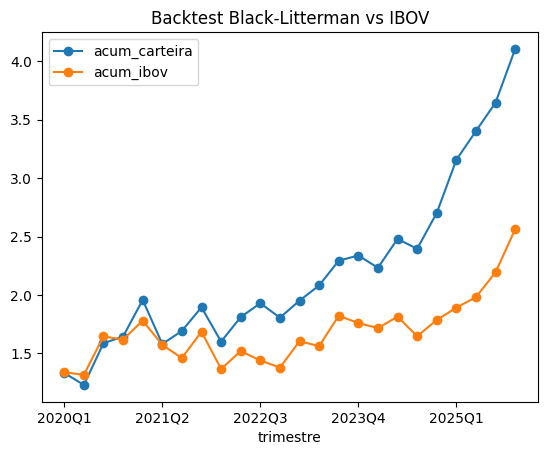

In [61]:
# ---------------------------------------------------------------------------
# Rodar o backtest. metodo="individual" ou "grid".
# ---------------------------------------------------------------------------
resumo, pesos_df = rodar_backtest("dados_backtest.csv",
                                  "../dados/ranking.csv",
                                  fatores="nefin_factors.csv",
                                  metodo="individual")
resumo.to_csv("backtest_bl_individual.csv", index=False)
pesos_df.to_csv("pesos_backtest.csv")
print(resumo)

# carteira acumulada vs IBOV
resumo.plot(x="trimestre", y=["acum_carteira", "acum_ibov"], marker="o",
            title="Backtest Black-Litterman vs IBOV")

# peso de cada ativo por trimestre (exibido ao fim do backtest)
pesos_df

In [62]:
def metricas_performance(resumo, rf_anual=None, fatores=None, periodos_ano=4, alpha=0.95):
    """
    Métricas do backtest a partir do `resumo` (saída de rodar_backtest):
      - retorno acumulado (carteira, IBOV e a diferença),
      - CAGR e volatilidade anualizada,
      - Sharpe anualizado do período E Sharpe expandindo ao longo do tempo,
      - max drawdown e a série de drawdown,
      - VaR e CVaR históricos (perda, ex-post) sobre os retornos trimestrais
        realizados, no nível de confiança `alpha`.
    rf_anual: taxa livre de risco anual; se None, é estimada do Risk_Free do Nefin
    (passe `fatores` = DataFrame ou caminho do nefin_factors.csv). periodos_ano=4
    porque o rebalanceamento é trimestral.
    Retorna (metricas, resumo_aug):
      metricas   : DataFrame [carteira, ibov] por métrica
      resumo_aug : resumo + dd_carteira, dd_ibov, dif_acum, sharpe_expand
    """
    if rf_anual is None:
        if isinstance(fatores, str):
            fatores = obter_fatores_nefin(fatores)
        rf_anual = ((1 + fatores["Risk_Free"].mean()) ** 12 - 1
                    if isinstance(fatores, pd.DataFrame) and "Risk_Free" in fatores else 0.0)
    rf_p = (1 + rf_anual) ** (1 / periodos_ano) - 1
    raiz = np.sqrt(periodos_ano)

    r = resumo.copy().reset_index(drop=True)
    r["dd_carteira"] = r["acum_carteira"] / r["acum_carteira"].cummax() - 1
    r["dd_ibov"]     = r["acum_ibov"]     / r["acum_ibov"].cummax() - 1
    r["dif_acum"]    = r["acum_carteira"] - r["acum_ibov"]
    exc = r["retorno_carteira"] - rf_p
    r["sharpe_expand"] = (exc.expanding(min_periods=2).mean()
                          / r["retorno_carteira"].expanding(min_periods=2).std(ddof=1)) * raiz

    pct = int(round(alpha * 100))

    def _stats(ret, acum):
        n = len(ret)
        vol = ret.std(ddof=1)
        q = ret.quantile(1 - alpha)              # quantil da cauda (ex.: 5%)
        cauda = ret[ret <= q]
        return {
            "retorno_acum": acum.iloc[-1] - 1,
            "cagr":         acum.iloc[-1] ** (periodos_ano / n) - 1,
            "vol_anual":    vol * raiz,
            "sharpe":       ((ret.mean() - rf_p) / vol * raiz) if vol > 0 else np.nan,
            "max_drawdown": (acum / acum.cummax() - 1).min(),
            f"VaR_{pct}":   -q,                                   # perda (positiva)
            f"CVaR_{pct}":  -cauda.mean() if len(cauda) else -q,  # perda esperada na cauda
        }

    metricas = pd.DataFrame({
        "carteira": _stats(r["retorno_carteira"], r["acum_carteira"]),
        "ibov":     _stats(r["retorno_ibov"],     r["acum_ibov"]),
    })
    metricas.loc["rf_anual"] = [rf_anual, rf_anual]
    metricas.loc["dif_retorno_acum"] = [
        metricas.loc["retorno_acum", "carteira"] - metricas.loc["retorno_acum", "ibov"], np.nan]
    return metricas, r

                  carteira    ibov
retorno_acum        3.1055  1.5631
cagr                0.2654  0.1698
vol_anual           0.2448  0.2474
sharpe              0.6409  0.3014
max_drawdown       -0.1928 -0.2326
VaR_95              0.1433  0.1132
CVaR_95             0.1739  0.1531
rf_anual            0.1180  0.1180
dif_retorno_acum    1.5424     NaN


,trimestre,dif_acum,dd_carteira,dd_ibov,sharpe_expand
0,2020Q1,-0.005735,0.000000,0.000000,NaN
1,2020Q2,-0.086218,-0.077048,-0.016631,0.688986
2,2020Q3,-0.058106,0.000000,0.000000,1.364627
3,2020Q4,0.025553,0.000000,-0.016228,1.184119
4,2021Q1,0.176991,0.000000,0.000000,1.462407
5,2021Q2,0.007606,-0.192803,-0.116873,0.652582
6,2021Q3,0.232429,-0.135480,-0.180061,0.675647
7,2021Q4,0.208411,-0.032362,-0.053214,0.765680
8,2022Q1,0.234177,-0.182338,-0.232556,0.431062
9,2022Q2,0.290965,-0.075155,-0.146601,0.525289


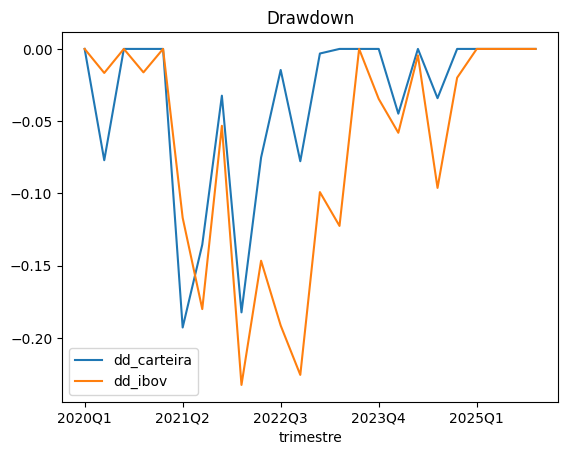

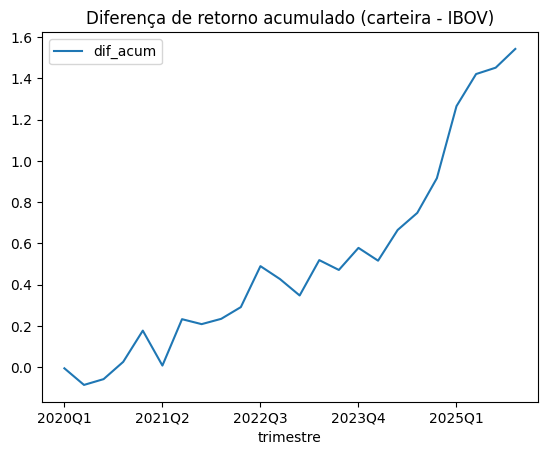

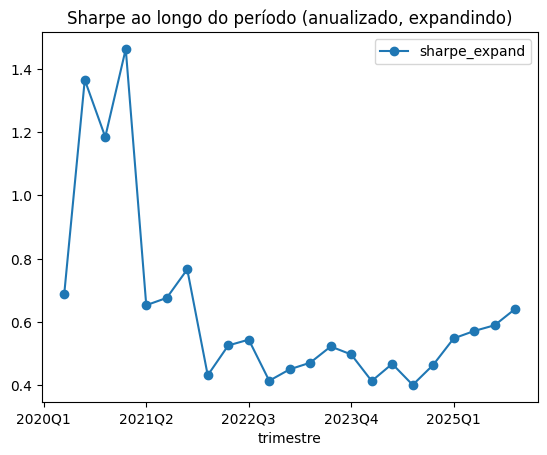

In [63]:
# Métricas do backtest (Sharpe, drawdown, diferença de retorno acumulado)
metricas, resumo_m = metricas_performance(resumo, fatores="nefin_factors.csv")
print(metricas.round(4))

# drawdown e diferença de retorno acumulado ao longo do período
resumo_m.plot(x="trimestre", y=["dd_carteira", "dd_ibov"], title="Drawdown")
resumo_m.plot(x="trimestre", y="dif_acum",
              title="Diferença de retorno acumulado (carteira - IBOV)")
resumo_m.plot(x="trimestre", y="sharpe_expand", marker="o",
              title="Sharpe ao longo do período (anualizado, expandindo)")

resumo_m[["trimestre", "dif_acum", "dd_carteira", "dd_ibov", "sharpe_expand"]]

In [64]:
def rodar_e_avaliar(dados_backtest, ranking, fatores="nefin_factors.csv",
                    metodo="individual", risco="variancia", **kwargs):
    """
    Roda o backtest (rodar_backtest) com um metodo de risco e ja avalia
    (metricas_performance). risco: 'variancia' | 'min_cvar' | 'cvar_restrito'.
    Retorna (resumo_aug, pesos_df, metricas).
    """
    resumo, pesos = rodar_backtest(dados_backtest, ranking, fatores=fatores,
                                   metodo=metodo, risco=risco, **kwargs)
    met, resumo_aug = metricas_performance(resumo, fatores=fatores)
    return resumo_aug, pesos, met

In [65]:
def comparar_metodos_risco(dados_backtest, ranking, fatores="nefin_factors.csv",
                           metodo="individual",
                           riscos=("variancia", "min_cvar", "min_cvar_alvo", "cvar_restrito"),
                           **kwargs):
    """
    Roda o backtest para cada metodo de risco e compara as metricas lado a lado.
    Retorna (tabela, resultados):
      tabela     : DataFrame metrica x [riscos... + ibov]  (carteira)
      resultados : {risco: {'resumo': resumo_aug, 'pesos': pesos_df, 'metricas': met}}
    """
    metricas_cart, resultados, met = {}, {}, None
    for r in riscos:
        print(f"=== risco = {r} ===")
        resumo, pesos = rodar_backtest(dados_backtest, ranking, fatores=fatores,
                                       metodo=metodo, risco=r, **kwargs)
        met, resumo_aug = metricas_performance(resumo, fatores=fatores)
        metricas_cart[r] = met["carteira"]
        resultados[r] = {"resumo": resumo_aug, "pesos": pesos, "metricas": met}
    tabela = pd.DataFrame(metricas_cart)
    if met is not None:
        tabela["ibov"] = met["ibov"]
    return tabela, resultados

=== risco = variancia ===
Preços do cache (precos_backtest_bl.parquet): 67 tickers, 2049 dias
=== risco = min_cvar ===
Preços do cache (precos_backtest_bl.parquet): 67 tickers, 2049 dias
=== risco = min_cvar_alvo ===
Preços do cache (precos_backtest_bl.parquet): 67 tickers, 2049 dias
=== risco = cvar_restrito ===
Preços do cache (precos_backtest_bl.parquet): 67 tickers, 2049 dias
  [cvar_restrito] cvar_max=0.150 inviavel (CVaR minimo atingivel ~0.176) -> fallback p/ min_cvar
  [cvar_restrito] cvar_max=0.150 inviavel (CVaR minimo atingivel ~0.150) -> fallback p/ min_cvar
  [cvar_restrito] cvar_max=0.150 inviavel (CVaR minimo atingivel ~0.156) -> fallback p/ min_cvar
  [cvar_restrito] cvar_max=0.150 inviavel (CVaR minimo atingivel ~0.173) -> fallback p/ min_cvar
  [cvar_restrito] cvar_max=0.150 inviavel (CVaR minimo atingivel ~0.194) -> fallback p/ min_cvar
  [cvar_restrito] cvar_max=0.150 inviavel (CVaR minimo atingivel ~0.194) -> fallback p/ min_cvar
  [cvar_restrito] cvar_max=0.150 in

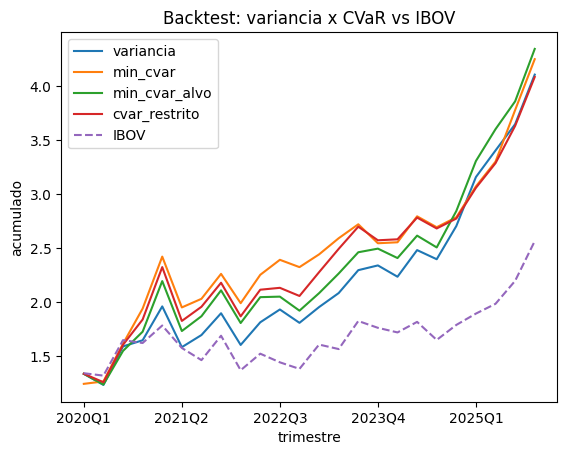

In [66]:
# Compara variancia x min_CVaR x CVaR_restrito (visoes = 'individual', alpha=95%)
tabela, resultados = comparar_metodos_risco(
    "dados_backtest.csv", "../dados/ranking.csv", fatores="nefin_factors.csv",
    metodo="individual", alpha=0.95, cvar_max=0.15, n_cenarios=5000, seed=42)
print(tabela.round(4))

# curvas acumuladas das tres carteiras vs IBOV
import matplotlib.pyplot as plt
ax = None
for r, d in resultados.items():
    ax = d["resumo"].plot(x="trimestre", y="acum_carteira", label=r, ax=ax)
list(resultados.values())[0]["resumo"].plot(x="trimestre", y="acum_ibov", label="IBOV",
                                             ax=ax, linestyle="--")
plt.title("Backtest: variancia x CVaR vs IBOV"); plt.ylabel("acumulado"); plt.show()

In [67]:
def calibrar_cvar(dados_backtest, ranking, fatores="nefin_factors.csv",
                  metodo="individual", inicio_janela="2018-01-01", delta=None, tau=0.1,
                  bounds=(0, 0.20), n_grid=3, alpha=0.95, n_cenarios=10000, horizonte=3,
                  seed=None, cenarios="t", nu=5, limiar=10, min_ativos=5,
                  cache_precos="precos_backtest_bl.parquet"):
    """
    Para cada trimestre, calcula o CVaR (nivel alpha) MINIMO atingivel pela
    carteira (portfolio min_cvar) - mesma montagem do rodar_backtest, sem
    look-ahead. Serve para escolher cvar_max no 'cvar_restrito': um cvar_max
    abaixo do minimo atingivel deixa a restricao inviavel (fallback p/ min_cvar).
    Retorna DataFrame [trimestre, cvar_min, n_ativos] e imprime uma sugestao.
    """
    bt = _ler_tabela(dados_backtest); bt["trimestre"] = bt["trimestre"].astype(str)
    rk = _ler_tabela(ranking)
    fat = fatores if isinstance(fatores, pd.DataFrame) else obter_fatores_nefin(fatores)
    trimestres = sorted(bt["trimestre"].dropna().unique())
    todos = sorted(bt["ticker"].dropna().unique())
    fim_geral = (pd.Period(trimestres[-1], "Q") + 1).end_time
    precos_todos = _precos_backtest(todos, inicio_janela, fim_geral, cache=cache_precos)

    linhas = []
    for Q in trimestres:
        ativos = obter_ativos_trimestre(bt, Q)
        tickers = ativos["ticker"].tolist()
        mcaps = ativos.set_index("ticker")["market_cap"]
        cut = pd.Period(Q, "Q").end_time
        cols = [t for t in tickers if t in precos_todos.columns]
        pw = precos_todos.loc[:cut, cols]
        pw = pw.dropna(axis=1, thresh=len(pw) - limiar).ffill().dropna()
        if pw.shape[1] < min_ativos:
            continue
        try:
            bl = preparar_bl(pw, fat, mcaps, delta=delta)
            ff = estimar_retornos_ff(bl["returns"], bl["fatores"], bl["tickers"])
            if metodo == "grid":
                bmv, sz = bm_size_do_ranking(rk, Q, bl["tickers"])
                P, Qv, Om, tks = opiniao_grid(ff["retornos_estimados"], bl["cov"],
                                              bmv, sz, tau=tau, n=n_grid)
            else:
                P, Qv, Om, tks = opiniao_individual(ff["retornos_estimados"],
                                                    ff["var_residuos"], bl["tickers"])
            mu = posterior_bl(bl["cov"], bl["prior"], P, Qv, Om, tks, tau=tau)

            # mesmos cenarios do otimizar_min_cvar -> CVaR minimo atingivel
            cen = gerar_cenarios(bl["returns"], tks, horizonte, n_cenarios, seed,
                                 tipo=cenarios, nu=nu)
            cols2 = list(cen.columns)
            lb, ub = bounds; ub = max(ub, 1.0 / len(cols2) + 1e-9)
            mu_h = (1 + pd.Series(mu).reindex(cols2)) ** horizonte - 1
            ec = EfficientCVaR(mu_h, cen, beta=alpha, weight_bounds=(lb, ub))
            ec.min_cvar()
            linhas.append({"trimestre": Q, "cvar_min": ec.portfolio_performance()[1],
                           "n_ativos": len(cols2)})
        except Exception as e:
            print(f"  {Q}: pulado ({e})")
            continue

    df = pd.DataFrame(linhas)
    if not df.empty:
        s = df["cvar_min"]
        print(f"\nCVaR minimo atingivel (nivel {int(alpha*100)}%, trimestral):")
        print(f"  min={s.min():.3f}  mediana={s.median():.3f}  max={s.max():.3f}")
        print(f"Para cvar_restrito sem fallback:")
        print(f"  cvar_max >= {s.max():.3f}  -> viavel em TODOS os trimestres")
        print(f"  cvar_max ~ {s.quantile(0.9):.3f}  -> viavel em ~90% dos trimestres")
    return df

In [68]:
# Calibrar cvar_max: ver o CVaR minimo atingivel por trimestre
# cal = calibrar_cvar("dados_backtest.csv", "../dados/ranking.csv",
#                     fatores="nefin_factors.csv", metodo="individual",
#                     alpha=0.95, n_cenarios=5000, seed=42)
# print(cal.describe())
# # depois, use o cvar_max sugerido (>= max) no comparar_metodos_risco:
# # comparar_metodos_risco(..., cvar_max=<valor>, bounds=(0, 0.25))